# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

### Step 1. Load the data

In [2]:
df = pd.read_csv("../../../datasets/Salary Data.csv")

In [3]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [4]:
df.columns

Index(['Experience Years', 'Salary'], dtype='str')

### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
x = df[["Experience Years"]] 
y = df["Salary"]

### Step 2.b print the type of each

In [6]:
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
from pandas.api.types import is_numeric_dtype
if is_numeric_dtype (y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"  

print (f"Target type : {target_type}")
print (f"Machine Learning Task: {ml_task}")

Target type : Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
x.shape
y.shape

(40,)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [10]:
print("x summary:")
print(x.describe())

print("\ny summary:")
print(y.describe())

x summary:
       Experience Years
count         40.000000
mean           5.152500
std            2.663715
min            1.100000
25%            3.200000
50%            4.600000
75%            6.875000
max           10.500000

y summary:
count        40.000000
mean      74743.625000
std       25947.122885
min       37731.000000
25%       56878.250000
50%       64472.500000
75%       95023.250000
max      122391.000000
Name: Salary, dtype: float64


### Step 5. Plot the feature vs the target

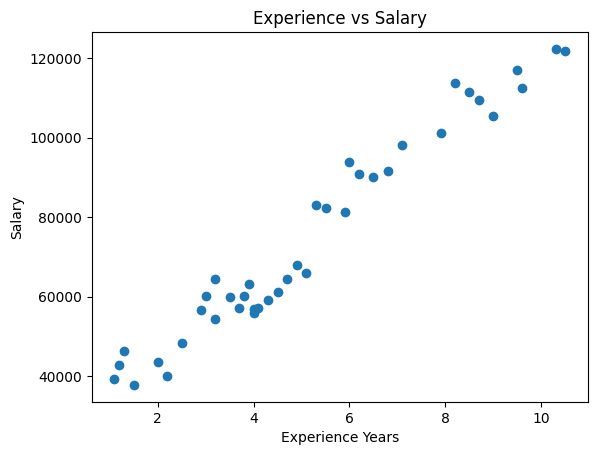

In [11]:
plt.scatter(x, y)
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [12]:
correlation_value = df['Experience Years'].corr(df['Salary'])

if correlation_value > 0:
    relationship = "Increasing (Positive Correlation)"
elif correlation_value < 0:
    relationship = "Decreasing (Negative Correlation)"
else:
    relationship = "None (No Correlation)"

print(f"Correlation Coefficient: {correlation_value:.2f}")
print(f"The relationship is: {relationship}")

Correlation Coefficient: 0.98
The relationship is: Increasing (Positive Correlation)


### Step 7. Initialize a regression model

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32, 1)
X_test shape: (8, 1)
y_train shape: (32,)
y_test shape: (8,)


### Step 9.a Train the model on the training set

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [17]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 9408.03127250658
Intercept: 26716.250176145535


### Step 9.c how much salary does a person get with 2 years of experience?

In [18]:
pred_salary_2_years = model.predict(pd.DataFrame({'Experience Years': [2]}))
print(f"Estimated salary for 2 years of experience: {pred_salary_2_years[0]:.2f}")

Estimated salary for 2 years of experience: 45532.31


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [19]:
salary_increase_6_months = slope * 0.5
print(f"Salary increase for 6 months of experience: {salary_increase_6_months:.2f}")

Salary increase for 6 months of experience: 4704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [20]:
pred_salary_0_years = model.predict(pd.DataFrame({'Experience Years': [0]}))
print(f"Estimated salary for 0 years of experience: {pred_salary_0_years[0]:.2f}")

Estimated salary for 0 years of experience: 26716.25


### Step 10. Evaluate the model on the test set

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("R^2 score:", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R^2 score: 0.9068577573647874
MAE: 6419.911069460598
MSE: 48077731.16919359


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [23]:
comparison = sample_X.copy()
comparison["True Salary"] = sample_y.values
comparison["Predicted Salary"] = sample_pred
comparison["Difference"] = comparison["True Salary"] - comparison["Predicted Salary"]

print(comparison)

    Experience Years  True Salary  Predicted Salary   Difference
19               4.5        61111      69052.390902 -7941.390902
16               4.0        56957      64348.375266 -7391.375266
15               4.0        55794      64348.375266 -8554.375266


### Step 12. Plot the data and the regression line

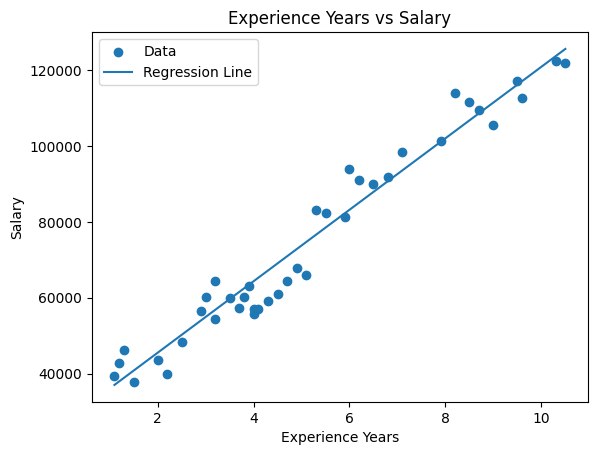

In [28]:
import matplotlib.pyplot as plt

y_line = model.predict(x)

plt.scatter(x.iloc[:, 0], y, label="Data")
plt.plot(x.iloc[:, 0], y_line, label="Regression Line")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")
plt.legend()
plt.show()